In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [3]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [4]:
tf.test.is_built_with_cuda()

False

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [6]:
x_train.shape

(50000, 32, 32, 3)

the 3 in the last is for RGB values of an image

In [7]:
def plot_sample(index):
    plt.figure(figsize=(3,1))
    plt.imshow(x_train[index])

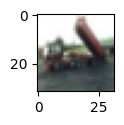

In [8]:
plot_sample(2)

In [9]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

Here the clasees is a text array of the y index 

In [10]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [11]:
classes[y_train[2][0]]

'truck'

In [12]:
X_train_scaled = x_train / 255 # Scalling the training samples
X_test_scaled = x_test / 255

In [13]:
# Now we will do one hot encoding for y train samples
# for we have an api in keras tensorflow
y_train_categorical = keras.utils.to_categorical(
    y_train,num_classes=10
)

In [14]:
y_train_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [15]:
y_test_categorical = keras.utils.to_categorical(
    y_test,num_classes=10)

In [16]:
y_test_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [24]:
model = keras.Sequential([
    # Input Layer
    keras.layers.Flatten(input_shape=(32,32,3)),

    # Hidden Layers
    keras.layers.Dense(800,activation='relu'), # In hidden layers activation relu is preffered
    keras.layers.Dense(400,activation='relu'), # In hidden layers activation relu is preffered


    # Output layer
    keras.layers.Dense(10,activation='sigmoid'), # if you dont give any activation function its linear by default so it wont do any activation

])

c:\Users\Nabeel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.compile(
    optimizer='SGD',
    loss='categorical_crossentropy', # here we used categorical_crossentropy because when we use one hot encoding we use this but in out previous hand written digits classification we used sparse_categorical_crossentropy
    metrics=['accuracy']
)

In [48]:
model.fit(X_train_scaled,y_train_categorical,epochs=50)

KeyboardInterrupt: 

In [49]:
model.evaluate(X_test_scaled,y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5299 - loss: 1.7061


[1.6981818675994873, 0.526199996471405]

In [59]:
y_test[:10]

array([[3],
       [8],
       [8],
       [0],
       [6],
       [6],
       [1],
       [6],
       [3],
       [1]], dtype=uint8)

In [51]:
X_test_scaled[0].shape

(32, 32, 3)

In [ ]:
pred = model.predict(X_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [72]:
"Pred " + classes[np.argmax(pred[2])], "Truth "+ classes[y_test[2][0]]

('Pred airplane', 'Truth ship')

In [85]:
for i in range(50):
    if np.argmax(pred[i]) != y_test[i]:
        print(f"Predicted - [{np.argmax(pred[i])} {classes[np.argmax(pred[2])]}], Truth - {y_test[i]} { classes[y_test[i][0]]}, Index - {i}")

Predicted - [0 airplane], Truth - [8] ship, Index - 2
Predicted - [7 airplane], Truth - [3] cat, Index - 8
Predicted - [1 airplane], Truth - [9] truck, Index - 11
Predicted - [1 airplane], Truth - [9] truck, Index - 14
Predicted - [3 airplane], Truth - [5] dog, Index - 16
Predicted - [3 airplane], Truth - [7] horse, Index - 17
Predicted - [1 airplane], Truth - [7] horse, Index - 20
Predicted - [0 airplane], Truth - [4] deer, Index - 22
Predicted - [4 airplane], Truth - [5] dog, Index - 24
Predicted - [5 airplane], Truth - [4] deer, Index - 26
Predicted - [7 airplane], Truth - [0] airplane, Index - 27
Predicted - [4 airplane], Truth - [5] dog, Index - 31
Predicted - [8 airplane], Truth - [4] deer, Index - 32
Predicted - [3 airplane], Truth - [5] dog, Index - 33
Predicted - [9 airplane], Truth - [2] bird, Index - 35
Predicted - [6 airplane], Truth - [4] deer, Index - 36
Predicted - [7 airplane], Truth - [4] deer, Index - 40
Predicted - [7 airplane], Truth - [5] dog, Index - 42
Predicted 

In [86]:
x_test.shape

(10000, 32, 32, 3)

In [ ]:
def get_model():
    model = keras.Sequential([
        # Input Layer
        keras.layers.Flatten(input_shape=(32,32,3)),
        # Hidden Layers
        keras.layers.Dense(800,activation='relu'), 
        keras.layers.Dense(400,activation='relu'), 
        # Output layer
        keras.layers.Dense(10,activation='sigmoid'), 

    ])

    model.compile(
        optimizer='SGD',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [88]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(x_train_scaled,y_train_categorical,epochs=1)

c:\Users\Nabeel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


AttributeError: 'NoneType' object has no attribute 'fit'